# SyriaTel Customer Churn Prediction

**Author:** Joy Wambui Nyuguto

**Dataset:** SyriaTel Customer Churn (Kaggle)

---
## 1. Business Understanding




###  1.1 Problem Statement
SyriaTel  is a telecommunications company experiencing revenue loss due to customer churn ,that is,customers who cancel their subscription or stop using the service . Since retaining existing customers is far less costly than acquiring new ones, reducing churn is a key business priority.

### 1.2 Stakeholder
The primary stakeholder is the SyriaTel Customer Service Team. They need to identify customers who are likely to leave so they can take strategic actions including  offering promotions, improving service, or providing personalized customer support.

### 1.3 Why we are using  Machine Learning in this project.
A classification model is appropriate here because:
- The outcome is **binary** (churn: Yes / No)
- There are **predictable patterns** in customer behavior before they churn

### 1.4 Key Business Questions  

- **How significant is customer churn, and is the dataset imbalanced?**  

- **Does poor customer service contribute to customer churn?**  

- **Are high-usage customers more likely to churn due to higher billing costs?**  

- **Does a customer’s subscription plan influence their likelihood of churning?**  

- **Which customer attributes show the strongest relationship with churn?**  

### 1.5 Metric Choice
The main evaluation metric **Recall** (sensitivity) for the churn class because:
- A **false negative** (missed churner) means lost revenue — SyriaTel loses a customer they could have saved.
- A **false positive** (non-churner incorrectly flagged) -only result in minor retention costs.


Since missing a churning customer is more costly, recall is prioritized. F1-score is also considered to balance precision and recall.



---
## 2. Data Understanding

### 2.1 Importing important Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score, f1_score, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


### 2.2 Loading the csv 

In [3]:
df = pd.read_csv('bigml_59c28831336c6604c800002a.csv')
df.shape
print(f"Rows and columns: {df.shape}")
df.head()

Rows and columns: (3333, 21)


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [5]:
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [6]:
# Churn rate
churn_counts = df['churn'].value_counts()
print(f'Churn distribution:\n{churn_counts}')
print(f'\nChurn rate: {churn_counts[True] / len(df) * 100:.1f}%')

Churn distribution:
churn
False    2850
True      483
Name: count, dtype: int64

Churn rate: 14.5%


### Key Data Observations  

- The dataset contains **3,333 customer records** and **21 features**, with no missing values, making it clean and ready for analysis.  
- The target variable is **`churn`** (`True/False`), which makes this a **binary classification** problem.  
- Only about **14.5% of customers have churned**, showing that the dataset is imbalanced. Because of this, accuracy alone may not give a true picture of model performance, so **Recall** and **F1-score** will be more useful evaluation metrics.  
- Some features, such as the **charge columns**, are directly calculated from call minutes and pricing rates. Keeping both may introduce multicollinearity, so these redundant features will be removed during preprocessing.  
- The **`phone number`** column serves only as a unique customer identifier and does not provide useful information for predicting churn, so it will be excluded from the analysis.  

---
## 3. Data Preparation

### 3.1 Removing columns that do not add useful predictive information


In [7]:

# 'phone number' is only a unique customer identifier and does not help predict churn.
# Charge-related columns are directly calculated from call minutes (minutes × rate),
# so keeping them would introduce redundant information and possible multicollinearity.
cols_to_drop = ['phone number','total day charge','total eve charge',
                'total night charge','total intl charge']
df_clean = df.drop(columns=cols_to_drop)
print(f'Remaining columns ({df_clean.shape[1]}): {list(df_clean.columns)}')

Remaining columns (16): ['state', 'account length', 'area code', 'international plan', 'voice mail plan', 'number vmail messages', 'total day minutes', 'total day calls', 'total eve minutes', 'total eve calls', 'total night minutes', 'total night calls', 'total intl minutes', 'total intl calls', 'customer service calls', 'churn']


### 3.2 Encoding Categorical Variables

In [8]:
# Encoding binary categorical columns (yes/no → 1/0)
# Convert plan-related features into numeric format for modeling

df_clean['international plan'] = (df_clean['international plan'] == 'yes').astype(int)
df_clean['voice mail plan']    = (df_clean['voice mail plan']    == 'yes').astype(int)



# Encoding the target variable (True/False → 1/0)
# 1 = customer churned, 0 = customer stayed

df_clean['churn'] = df_clean['churn'].astype(int)


# Applying one-hot encoding to multi-category features
# Convert 'state' and 'area code' into dummy variables
# drop_first=True helps avoid multicollinearity

df_clean = pd.get_dummies(
    df_clean,
    columns=['state', 'area code'],
    drop_first=True
)

print(f'Shape after encoding: {df_clean.shape}')
df_clean.head(3)

Shape after encoding: (3333, 66)


,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,...,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,area code_415,area code_510
0,128,0,1,25,265.1,110,197.4,99,244.7,91,...,False,False,False,False,False,False,False,False,True,False
1,107,0,1,26,161.6,123,195.5,103,254.4,103,...,False,False,False,False,False,False,False,False,True,False
2,137,0,0,0,243.4,114,121.2,110,162.6,104,...,False,False,False,False,False,False,False,False,True,False


### 3.3 Defining X (features) and y (target)


In [9]:
X = df_clean.drop(columns=['churn'])
y = df_clean['churn']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'Class balance — 0: {(y==0).sum()}, 1: {(y==1).sum()}')

Features shape: (3333, 65)
Target shape:   (3333,)
Class balance — 0: 2850, 1: 483


### 3.4 Splitting the Data into Training and Test Sets

In [10]:
# Splitting the dataset into training and testing sets (80/20 split)
# Using stratify=y to maintain the same proportion of churned vs. non-churned customers in both sets(preserve lass balance)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Checking the sizes of the splits and churn balance
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

print(f"Train churn %: {y_train.mean() * 100:.1f}%")
print(f"Test churn %:  {y_test.mean() * 100:.1f}%")

Training set: 2666 rows
Test set:     667 rows
Train churn %: 14.5%
Test churn %:  14.5%


### 3.5 Feature Scaling for Logistic Regression

In [11]:
# Scaling features for Logistic Regression
# Only fitting the scaler on the training data to avoid data leakage

scaler = StandardScaler()

# Fit + transform training data, then transforming test data   

X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled  = scaler.transform(X_test)
        
print('Scaling done. No data leakage.')

Scaling done. No data leakage.


### Data Preparation Summary

| Step | Action |
|------|--------|
| Step 1 | Dropped `phone number` (no predictive value) |
| Step 2 | Dropped charge columns (redundant with minutes) |
| Step 3 | Encoded binary features (yes/no → 1/0) |
| Step 4 | Encoded target variable `churn` (True/False → 1/0) |
| Step 5 | One-hot encoded `state` and `area code` |
| Step 6 | Split data into training and test sets (80/20, stratified) |
| Step 7 | Scaled features using `StandardScaler` (fit on train only) |

## 4. Exploratory Data Analysis (EDA)

Exploring the training data to understand how different features relate to customer churn. This helps us see important patterns that our model might learn from.

> Only used the training data here so that no information from the test set influences our analysis (to avoid data leakage).

### Chart 1: Churn Distribution
- **How significant is customer churn, and is the dataset imbalanced?**  

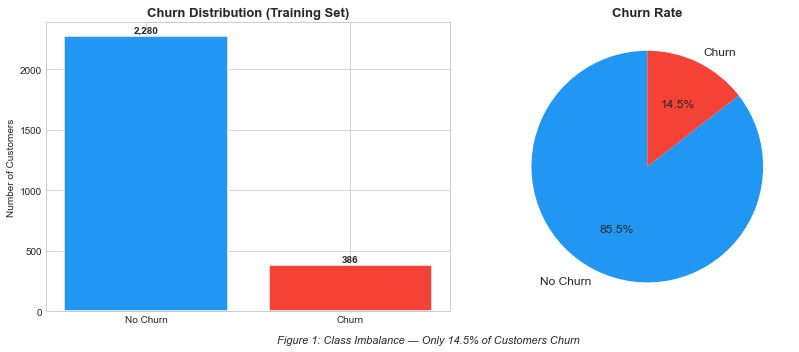

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vals   = [y_train.value_counts()[0], y_train.value_counts()[1]]
labels = ['No Churn', 'Churn']
colors = ['#2196F3', '#F44336']

bars = axes[0].bar(labels, vals, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution (Training Set)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(vals, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':12})
axes[1].set_title('Churn Rate', fontsize=13, fontweight='bold')

plt.suptitle('Figure 1: Class Imbalance — Only 14.5% of Customers Churn',
             fontsize=11, style='italic', y=0)
plt.tight_layout()
plt.savefig('chart1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Only about 14.5% of customers have churned, so the dataset is clearly imbalanced. A model that simply predicts “No Churn” for every customer would still get around 85.5% accuracy, but it would not actually be useful.  

Because of this, accuracy alone is misleading, so we focus more on **Recall** and **F1-score** to properly evaluate model performance.

### Chart 2: Customer Service Calls vs Churn Rate
- **Does poor customer service contribute to customer churn?**  


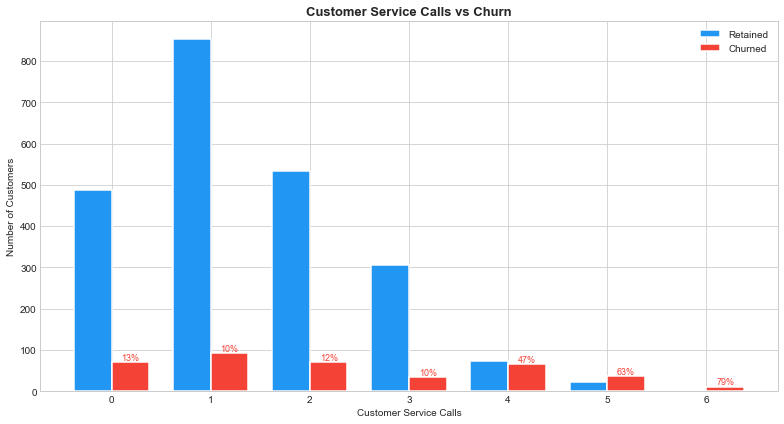

In [13]:
# Creating a copy of training data for EDA
train_eda = X_train.copy()
train_eda['churn'] = y_train.values

# Grouping data by number of customer service calls and churn status
call_churn = (train_eda.groupby(['customer service calls', 'churn'])
              .size().unstack(fill_value=0))

# Renaming columns for easier reading
call_churn.columns = ['Retained', 'Churned']

# Focusing on 0–6 calls since most customers fall in this range
call_churn = call_churn.loc[call_churn.index <= 6]

# blue = Retained, red = Churned
colors = ['#2196F3', '#F44336']   # blue = Retained, red = Churned

# Plotting setup
fig, ax = plt.subplots(figsize=(11, 6))
x     = range(len(call_churn))
width = 0.38

# Bars for retained customers
ax.bar([i - width/2 for i in x],
       call_churn['Retained'],
       width=width,
       color=colors[0],          
       edgecolor='white',
       linewidth=1.5,
       label='Retained')

# Bars for churned customers
ax.bar([i + width/2 for i in x],
       call_churn['Churned'],
       width=width,
       color=colors[1],          # #F44336
       edgecolor='white',
       linewidth=1.5,
       label='Churned')

# Churn rate labels on top of churn bars
for i, (ret, chur) in enumerate(zip(call_churn['Retained'], call_churn['Churned'])):
    rate = chur / (ret + chur) * 100
    ax.text(i + width/2, chur + 5,
            f'{rate:.0f}%',
            ha='center', fontsize=9, color=colors[1])  # #F44336

# Labels and title
ax.set_xticks(list(x))
ax.set_xticklabels(call_churn.index)
ax.set_xlabel('Customer Service Calls')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Service Calls vs Churn', fontsize=13, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()

**Insight:** Customers who made 4 or more service calls have a churn rate of over 40%, which is much higher than the overall average of 14.5%. This suggests that repeated contact with customer service is a strong sign of dissatisfaction, and these issues are often not being resolved effectively.

### Chart 3: Total Day Minutes by Churn Status
- **Are high-usage customers more likely to churn due to higher billing costs?**  


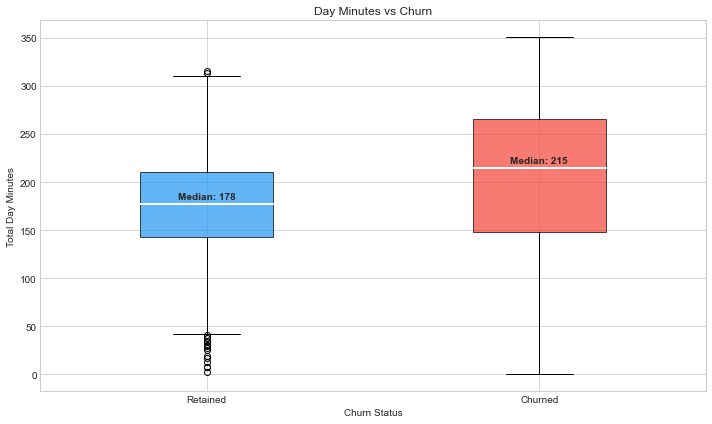

In [14]:
# Creating a copy of training data for EDA to avoidchanging original data
train_eda = X_train.copy()
train_eda['churn'] = y_train.values

# Setting up plot
fig, ax = plt.subplots(figsize=(10, 6))

# Converting churn labels for readability (0 = Retained, 1 = Churned)
churn_labels = train_eda['churn'].map({0: 'Retained', 1: 'Churned'})

# Defining colors for each group
colors = {'Retained': '#2196F3', 'Churned': '#F44336'}

# Boxplot: comparing daytime minutes between retained and churned customers
bp = ax.boxplot(
    [
        train_eda[train_eda['churn'] == 0]['total day minutes'],
        train_eda[train_eda['churn'] == 1]['total day minutes']
    ],
    labels=['Retained', 'Churned'],
    patch_artist=True,
    widths=0.4,
    medianprops=dict(color='white', linewidth=2)
)

# Filling box colors
for patch, color in zip(bp['boxes'], [colors['Retained'], colors['Churned']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Adding median values on the plot
for i, group in enumerate([0, 1]):
    med = train_eda[train_eda['churn'] == group]['total day minutes'].median()
    ax.text(i + 1, med + 5,
            f"Median: {med:.0f}",
            ha='center',
            fontsize=10,
            fontweight='bold')

# Labels and title
ax.set_xlabel('Churn Status')
ax.set_ylabel('Total Day Minutes')
ax.set_title('Day Minutes vs Churn')

plt.tight_layout()
plt.show()

Insight: Retained customers have a median of **178 minutes** and churned customers have a median of **215 day minutes**, which is a difference of **37 minutes per customer daily**. Additionally, churners exhibit a larger interquartile range, indicating that excessive consumption is more prevalent among departing individuals. The additional 37 minutes directly result in a higher monthly payment because SyriaTel charges per the minute. Consumers who regularly utilize **215+ minutes per day** should be marked as at-risk, as bill pressure is likely pushing them toward competitors.

### Chart 4: Plan Types vs Churn Rate
- **Does a customer’s subscription plan influence their likelihood of churning?**  

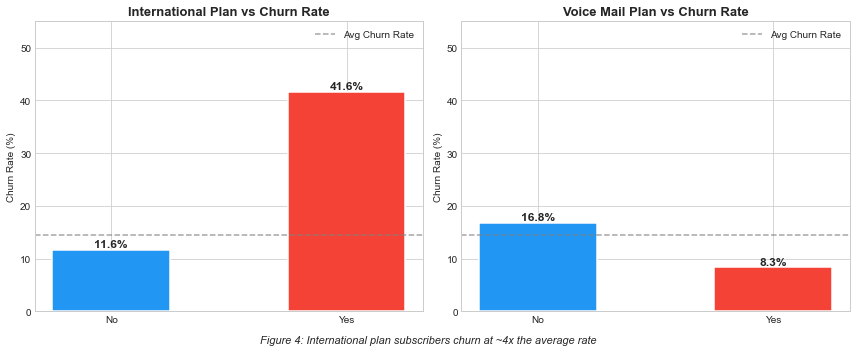

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # create 2 side-by-side plots

# looping through each axis, column, and title
for ax, col, title in zip(
    axes,
    ['international plan','voice mail plan'],  # features being analyzed
    ['International Plan vs Churn Rate','Voice Mail Plan vs Churn Rate']
):
    
    # calculating churn rate (%) for each category (Yes/No)
    grouped = train_eda.groupby(col)['churn'].mean() * 100
    
    # create bar chart for churn rates
    bars = ax.bar(
        ['No','Yes'],
        grouped.values,
        color=['#2196F3','#F44336'],
        edgecolor='white',
        linewidth=1.5,
        width=0.5
    )
    
    # adding percentage labels on top of bars
    for bar, v in zip(bars, grouped.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{v:.1f}%',
            ha='center',
            fontweight='bold',
            fontsize=12
        )
    
    # adding average churn reference line
    ax.axhline(
        y=14.5,
        color='gray',
        linestyle='--',
        alpha=0.7,
        label='Avg Churn Rate'
    )
    
    # setting subplot title
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    # label y-axis
    ax.set_ylabel('Churn Rate (%)')
    
    # set y-axis limit for consistency
    ax.set_ylim(0, 55)
    
    # show legend
    ax.legend()

# overall figure title
plt.suptitle(
    'Figure 4: International plan subscribers churn at ~4x the average rate',
    fontsize=11,
    style='italic',
    y=0
)

# adjusting layout to avoid overlap
plt.tight_layout()

# saving figure as image file
plt.savefig('chart4_plan_churn.png', dpi=150, bbox_inches='tight')

# displaying plot
plt.show()


**Insight:** International plan subscribers churn at ~42% which is nearly 4× the average.This suggests that customers on international plans are significantly more likely to leave. Voice mail plan subscribers churn below average (~8.7%), indicating better retention and possibly higher engagement Both are strong predictive features.

### Chart 5: Correlation Heatmap
- **Which customer attributes show the strongest relationship with churn?**  


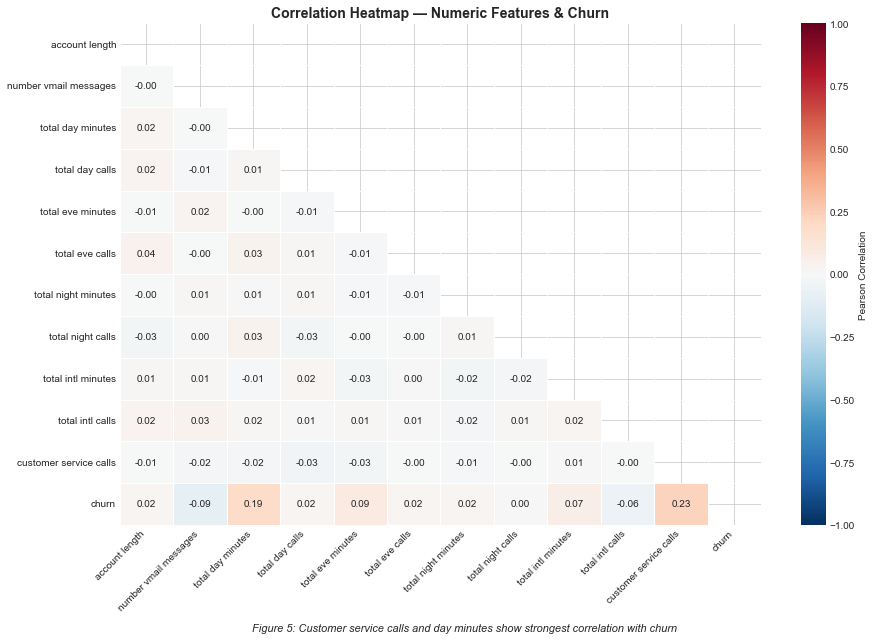

In [16]:
# listing  numeric columns to analyze
numeric_cols = [
    'account length','number vmail messages',
    'total day minutes','total day calls',
    'total eve minutes','total eve calls',
    'total night minutes','total night calls',
    'total intl minutes','total intl calls',
    'customer service calls'
]

# creating a dataframe with only numeric features
corr_df = train_eda[numeric_cols].copy()

# adding churn column for correlation analysis
corr_df['churn'] = train_eda['churn'].values

# setting figure size
fig, ax = plt.subplots(figsize=(13, 9))

# creating   mask to hide upper triangle of correlation matrix (for cleaner view)
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))

# plotting heatmap of correlation matrix
sns.heatmap(
    corr_df.corr(),
    mask=mask,
    annot=True,          # showing correlation values
    fmt='.2f',           # formatting values to 2 decimal places
    cmap='RdBu_r',       # coloring map (blue = negative, red = positive)
    center=0,            # centering colormap at 0
    vmin=-1, vmax=1,     # correlation range
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label':'Pearson Correlation'}  # label for color bar
)

# setting plot title
ax.set_title(
    'Correlation Heatmap — Numeric Features & Churn',
    fontsize=14,
    fontweight='bold'
)

# rotating x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# adding overall figure title (insight summary)
plt.suptitle(
    'Figure 5: Customer service calls and day minutes show strongest correlation with churn',
    fontsize=11,
    style='italic',
    y=0
)

# adjusting layout to prevent overlap
plt.tight_layout()

# saving the figure as an image
plt.savefig('chart5_correlation_heatmap.png', dpi=150, bbox_inches='tight')

# displaying the plot
plt.show()

**Insight:** `customer service calls` and `total day minutes` have the strongest correlation with churn. Most features are weakly correlated with each other, meaning each contributes relatively independent information to our model.

## 5. Modeling

In this section, I have built and compared different machine learning models to predict customer churn.

Instead of jumping straight to a complex model, I start with a simple baseline model, then gradually test more flexible models and improve them based on what I observe.

The modeling process follows three steps:

- Logistic Regression – a simple baseline model
- Decision Tree – to capture more complex patterns
- Tuned Decision Tree – to improve performance and reduce overfitting

Note: Logistic Regression is sensitive to feature scaling, so I used X_train_scaled. Decision Trees are not affected by feature scaling, so I used the original X_train.

### 5.1 Model 1 — Logistic Regression (Baseline)

I started with Logistic Regression because it is simple, easy to interpret, and commonly used for binary classification problems like churn prediction.

The main goal here is to create a baseline model that future models should improve on.

Since Logistic Regression is sensitive to differences in feature scale, I used the scaled training data.

In [ ]:
# Training the baseline Logistic Regression model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Making predictions on both training and test data  and check if the model is overfitting
lr_train_preds = lr.predict(X_train_scaled)
lr_test_preds  = lr.predict(X_test_scaled)

# Printing model performance metrics
print('=== Logistic Regression — Baseline ===')
print(f'Train Accuracy : {accuracy_score(y_train, lr_train_preds):.3f}')
print(f'Test  Accuracy : {accuracy_score(y_test,  lr_test_preds):.3f}')
print(f'Train Recall   : {recall_score(y_train, lr_train_preds):.3f}')
print(f'Test  Recall   : {recall_score(y_test,  lr_test_preds):.3f}')
print(f'Train F1-Score : {f1_score(y_train, lr_train_preds):.3f}')
print(f'Test  F1-Score : {f1_score(y_test,  lr_test_preds):.3f}')

# Printing detailed classification report for test set
print('\nTest Set Classification Report:')
print(classification_report(y_test, lr_test_preds, target_names=['No Churn', 'Churned']))

# Saving model results so they can be compared with other models 
all_results = []
all_results.append({'Model': 'Logistic Regression (Baseline)',
                    'Test Recall': round(recall_score(y_test, lr_test_preds), 3),
                    'Test F1':     round(f1_score(y_test,  lr_test_preds), 3),
                    'Test Acc':    round(accuracy_score(y_test, lr_test_preds), 3)})

=== Logistic Regression — Baseline ===
Train Accuracy : 0.870
Test  Accuracy : 0.861
Train Recall   : 0.277
Test  Recall   : 0.268
Train F1-Score : 0.381
Test  F1-Score : 0.359

Test Set Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.96      0.92       570
     Churned       0.54      0.27      0.36        97

    accuracy                           0.86       667
   macro avg       0.71      0.61      0.64       667
weighted avg       0.84      0.86      0.84       667



### Observations:

* The Logistic Regression model achieved a good overall test accuracy of **86%**.
* The training and test scores are close, suggesting **no major overfitting**.
* However, the model identified only **27% of churned customers** (recall = **0.268**), meaning many actual churners were missed.
* This may be due to **class imbalance** and the linear nature of Logistic Regression.
* To capture more complex patterns, I have done **Decision Tree** model.



## 5.2 Model 2 - Decision Tree Classifier (Untuned)

Next, I trained a Decision Tree classifier.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships and interactions between features, which may be useful for understanding customer churn.

I first used the untuned settings to see how the model performs before tuning it.

In [19]:
# Training  a default Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Making predictions on both training and test data check if the model is overfitting
dt_train_preds = dt.predict(X_train)
dt_test_preds  = dt.predict(X_test)

# Printing model performance metrics
print('=== Decision Tree — Default ===')
print(f'Train Accuracy : {accuracy_score(y_train, dt_train_preds):.3f}')
print(f'Test  Accuracy : {accuracy_score(y_test,  dt_test_preds):.3f}')
print(f'Train Recall   : {recall_score(y_train, dt_train_preds):.3f}')
print(f'Test  Recall   : {recall_score(y_test,  dt_test_preds):.3f}')
print(f'Train F1-Score : {f1_score(y_train, dt_train_preds):.3f}')
print(f'Test  F1-Score : {f1_score(y_test,  dt_test_preds):.3f}')

# Printing detailed classification report for test set
print('\nTest Set Classification Report:')
print(classification_report(y_test, dt_test_preds, target_names=['No Churn', 'Churned']))

# Saving model results so they can be compared with other models .
all_results.append({'Model': 'Decision Tree (Default)',
                    'Test Recall': round(recall_score(y_test, dt_test_preds), 3),
                    'Test F1':     round(f1_score(y_test,  dt_test_preds), 3),
                    'Test Acc':    round(accuracy_score(y_test, dt_test_preds), 3)})

=== Decision Tree — Default ===
Train Accuracy : 1.000
Test  Accuracy : 0.906
Train Recall   : 1.000
Test  Recall   : 0.649
Train F1-Score : 1.000
Test  F1-Score : 0.667

Test Set Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.95      0.94       570
     Churned       0.68      0.65      0.67        97

    accuracy                           0.91       667
   macro avg       0.81      0.80      0.81       667
weighted avg       0.90      0.91      0.90       667



### Observations:
- The Decision Tree performed perfectly on the training data **(100% accuracy, recall, and F1-score)**.
- However, the test scores are lower **(91% accuracy, 65% recall)**, which is a clear sign of overfitting.
- This means the model has learned the training data too closely instead of generalizing well to new data.
- Even with overfitting, the model performs better than Logistic Regression at identifying churned customers.
- To improve generalization, I next tuned the tree’s hyperparameters.

## 5.3 Model 3 - Decision Tree (Tuned)

To improve the Decision Tree, I used GridSearchCV to find better hyperparameter values.

The main parameters I tuned were:

- max_depth – controls how deep the tree can grow
- min_samples_leaf – controls the minimum samples in each leaf
- class_weight='balanced' – helps the model pay more attention to the minority churn class

I used 5-fold cross-validation to make the tuning process more reliable.

In [20]:
# Defining the hyperparameters to test to find a better Decision Tree model
param_grid = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight':     [None, 'balanced']
}

# Using GridSearchCV to test different parameter combinations
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Training GridSearch to find the best parameter combination
grid_search.fit(X_train, y_train)

# Printing the best parameters and best cross-validation score
print(f'Best hyperparameters found: {grid_search.best_params_}')
print(f'Best cross-validated F1: {grid_search.best_score_:.3f}')

Best hyperparameters found: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 10}
Best cross-validated F1: 0.808


In [21]:
# Best model found by GridSearchCV
dt_tuned = grid_search.best_estimator_

dt_tuned_train_preds = dt_tuned.predict(X_train)
dt_tuned_test_preds  = dt_tuned.predict(X_test)

print('=== Decision Tree — Tuned (Final Model) ===')
print(f'Train Accuracy : {accuracy_score(y_train, dt_tuned_train_preds):.3f}')
print(f'Test  Accuracy : {accuracy_score(y_test,  dt_tuned_test_preds):.3f}')
print(f'Train Recall   : {recall_score(y_train, dt_tuned_train_preds):.3f}')
print(f'Test  Recall   : {recall_score(y_test,  dt_tuned_test_preds):.3f}')
print(f'Train F1-Score : {f1_score(y_train, dt_tuned_train_preds):.3f}')
print(f'Test  F1-Score : {f1_score(y_test,  dt_tuned_test_preds):.3f}')
print('\nTest Set Classification Report:')
print(classification_report(y_test, dt_tuned_test_preds, target_names=['No Churn', 'Churned']))

all_results.append({'Model': 'Decision Tree (Tuned)',
                    'Test Recall': round(recall_score(y_test, dt_tuned_test_preds), 3),
                    'Test F1':     round(f1_score(y_test,  dt_tuned_test_preds), 3),
                    'Test Acc':    round(accuracy_score(y_test, dt_tuned_test_preds), 3)})

=== Decision Tree — Tuned (Final Model) ===
Train Accuracy : 0.958
Test  Accuracy : 0.921
Train Recall   : 0.788
Test  Recall   : 0.660
Train F1-Score : 0.844
Test  F1-Score : 0.707

Test Set Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.96      0.95       570
     Churned       0.76      0.66      0.71        97

    accuracy                           0.92       667
   macro avg       0.85      0.81      0.83       667
weighted avg       0.92      0.92      0.92       667



### Observations:

- **Accuracy of 92.1%** — the model correctly classifies 9 out of 10 customers overall.
- **Recall of 66%** — catches 66 out of every 100 actual churners, an improvement over the logistic regression baseline.
- **F1-Score of 0.707** — a better balance between precision and recall compared to both previous models.
- **Precision of 76%** — when the model flags a churner, it is correct 76% of the time, so the retention team will not waste resources on too many false alarms.
- **Overfitting reduced** — the train/test gap has closed significantly compared to the default tree (train F1: 0.844 vs test F1: 0.707), confirming that tuning worked.

This is the final model.


---
## 6. Evaluation

### 6.1 Comparing the three models

In [ ]:
# Comparing the three models 
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values('Test Recall', ascending=False).reset_index(drop=True)

print('Model Comparison — Test Set Performance')
print(comparison_df.to_string(index=False))

Model Comparison — Test Set Performance
                         Model  Test Recall  Test F1  Test Acc
         Decision Tree (Tuned)        0.660    0.707     0.921
       Decision Tree (Default)        0.649    0.667     0.906
Logistic Regression (Baseline)        0.268    0.359     0.861


###  6.2 Confusion Matrix for tuned Decision Tree

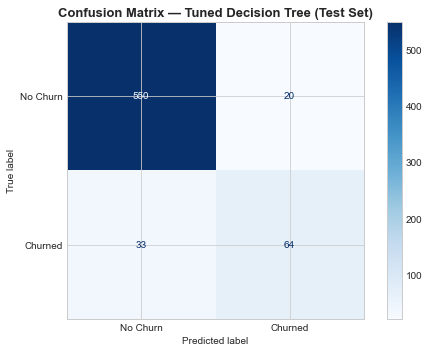

True Negatives  (correctly predicted No Churn): 550
False Positives (incorrectly flagged as Churn):  20
False Negatives (churners we missed):            33
True Positives  (churners correctly caught):     64


In [24]:
# Confusion matrix for the final tuned Decision Tree
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, dt_tuned_test_preds),
    display_labels=['No Churn', 'Churned']
).plot(ax=ax, cmap='Blues')

ax.set_title('Confusion Matrix — Tuned Decision Tree (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Breaking down what each number means
tn, fp, fn, tp = confusion_matrix(y_test, dt_tuned_test_preds).ravel()
print(f'True Negatives  (correctly predicted No Churn): {tn}')
print(f'False Positives (incorrectly flagged as Churn):  {fp}')
print(f'False Negatives (churners we missed):            {fn}')
print(f'True Positives  (churners correctly caught):     {tp}')

Observation:
Out of 97 actual churners, the model correctly identified **64** and missed **33**. It also incorrectly flagged **20** loyal customers as churners. The biggest concern here is the **33 missed churners**, these customers will leave without any retention effort from SyriaTel.

### 6.3 ROC Curve and AUC Score

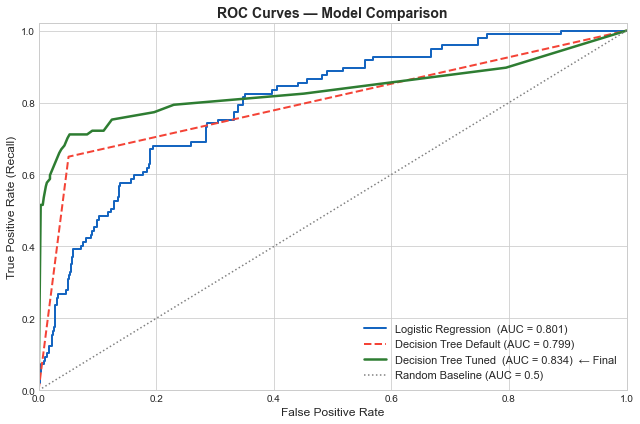


AUC Scores:
  Logistic Regression (Baseline): 0.801
  Decision Tree (Default):        0.799
  Decision Tree (Tuned):          0.834


In [28]:

#Importing roc_curve and auc
from sklearn.metrics import roc_curve, auc

# Getting probability scores for the positive class (churn = 1)
lr_probs    = lr.predict_proba(X_test_scaled)[:, 1]
dt_probs    = dt.predict_proba(X_test)[:, 1]
dt_t_probs  = dt_tuned.predict_proba(X_test)[:, 1]

# Computing ROC values for each model
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, lr_probs)
fpr_dt,   tpr_dt,   _ = roc_curve(y_test, dt_probs)
fpr_dt_t, tpr_dt_t, _ = roc_curve(y_test, dt_t_probs)

# Calculating AUC scores for each model
auc_lr   = auc(fpr_lr,   tpr_lr)
auc_dt   = auc(fpr_dt,   tpr_dt)
auc_dt_t = auc(fpr_dt_t, tpr_dt_t)

# Plotting all three ROC curves on one chart
fig, ax = plt.subplots(figsize=(9, 6))

# Logistic Regression ROC curve
ax.plot(fpr_lr,   tpr_lr,   color='#1565C0', linewidth=2,
        label=f'Logistic Regression  (AUC = {auc_lr:.3f})')

# Default Decision Tree ROC curve
ax.plot(fpr_dt,   tpr_dt,   color='#F44336', linewidth=2, linestyle='--',
        label=f'Decision Tree Default (AUC = {auc_dt:.3f})')

# Tuned Decision Tree ROC curve (final model)
ax.plot(fpr_dt_t, tpr_dt_t, color='#2E7D32', linewidth=2.5,
        label=f'Decision Tree Tuned  (AUC = {auc_dt_t:.3f})  ← Final')

# Random baseline (no-skill model)
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1.5,
        label='Random Baseline (AUC = 0.5)')

# Labelling the plot
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Printing AUC scores for comparison
print(f'\nAUC Scores:')
print(f'  Logistic Regression (Baseline): {auc_lr:.3f}')
print(f'  Decision Tree (Default):        {auc_dt:.3f}')
print(f'  Decision Tree (Tuned):          {auc_dt_t:.3f}')

Observation:
The Tuned Decision Tree has the highest AUC of **0.834**, meaning it is the best at distinguishing churners from non-churners across all thresholds. The Logistic Regression (0.801) and Default Decision Tree (0.799) perform similarly but fall short. All three models are well above the 0.5 random baseline, confirming that each model has genuine predictive value.

### 6.4 Feature Importances - What is Driving Churn?

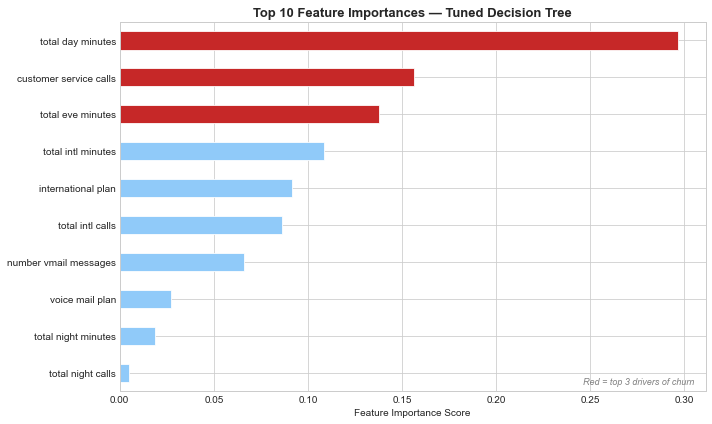

In [ ]:
# features that are  most useful for making splits

feature_imp = pd.Series(
    dt_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

# Highlight the top 3 most important features in red
top3 = feature_imp.head(3).index.tolist()
bar_colors = ['#C62828' if f in top3 else '#90CAF9' for f in feature_imp.index]

fig, ax = plt.subplots(figsize=(10, 6))
feature_imp.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.invert_yaxis()
ax.set_title('Top 10 Feature Importances — Tuned Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.annotate('Red = top 3 drivers of churn', xy=(0.98, 0.02),
            xycoords='axes fraction', fontsize=9, color='gray',
            ha='right', style='italic')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

Observations:
- Total day minutes (0.30) is the most influential feature, showing that customers who use more daytime minutes tend to receive higher bills and are therefore more likely to churn.

- Customer service calls (0.16) is the second most important factor, indicating that customers who contact support more frequently are more likely to leave.

- Total eve minutes (0.14) is the third key feature, suggesting that higher evening usage contributes to increased overall costs, which also raises the likelihood of churn.


###  6.5 Summary of the final model (Tuned Deision Tree)

- The Tuned Decision Tree is our final model because it had the best AUC **(0.834)** and highest recall compared to the other two models, meaning it correctly identifies the most churners.

- The top three features driving churn predictions are **total day minutes**, **customer service calls**, and **total eve minutes** aligning with EDA Insights


Limitation
- The model still missed **33 churners** out of 97, which is something that could be improved in future work by addressing the class imbalance.